In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import time, pickle, warnings
warnings.filterwarnings("ignore")

In [2]:
shuffle = True

## Data Loading

In [3]:
df0 = pd.read_csv("data/data.csv")
print(f"data shape: {df0.shape}")
df0["time"] = pd.to_datetime(df0["time"])
df0.head(3)

data shape: (36339, 32)


,time,Gas for paper,Hourly Production,Total water,Quantitative measurement of coiling scan frame,#1 Turbine motor side pressure,#1 Turbine Free Side Pressure,#1 Turbine Negative Pressure,#1 Turbine Negative Pressure.1,#1 Turbine Main Motor Current,...,#3 Turbine Negative Pressure.1,#3 Turbine Main Motor Current,#3 Vacuum Pump Motor Side Vibration,#3 Vacuum Pump Free Side Vibration,#4 Turbine Free Side Pressure,#4 Turbine Negative Pressure,#4 Turbine Negative Pressure.1,#4 Turbine Main Motor Current,#4 Vacuum Pump Motor Side vibration,#4 Vacuum pump free side vibration
0,2022-05-25 14:06:00,0.987,43.7,100.0,163.3,-32.3,-40.4,-36.3,93.0,79.4,...,91.0,83.0,0.7,13.0,-51.6,-51.6,100.0,73.1,13.3,2.4
1,2022-05-25 14:07:00,0.993,43.7,100.0,163.2,-32.5,-40.4,-36.4,93.0,79.1,...,91.0,83.0,0.7,13.2,-51.6,-51.6,100.0,73.4,13.3,2.4
2,2022-05-25 14:08:00,0.989,43.8,101.0,162.9,-32.7,-40.3,-36.5,93.0,78.7,...,91.0,83.2,0.7,13.4,-51.5,-51.5,100.0,73.4,13.3,2.4


#### Select Features and Target

plt.figure(figsize=(20, 3))
sns.heatmap(data = df0.iloc[:, 1:5].corr(), annot=True, cmap = 'RdBu')
plt.title('Correlation of output parameters', fontsize = 15)
plt.show()

In [4]:
target = "Hourly Production"
features = df0.columns[5:].to_list()

In [5]:
df = df0.copy()
df = df.set_index("time")
df = df[[target] + features]
df.head(3)

,Hourly Production,#1 Turbine motor side pressure,#1 Turbine Free Side Pressure,#1 Turbine Negative Pressure,#1 Turbine Negative Pressure.1,#1 Turbine Main Motor Current,#1 Vacuum Pump Motor Side vibration,#1 Free side vibration of vacuum pump,#2 Turbine motor side pressure,#2 Turbine free side pressure,...,#3 Turbine Negative Pressure.1,#3 Turbine Main Motor Current,#3 Vacuum Pump Motor Side Vibration,#3 Vacuum Pump Free Side Vibration,#4 Turbine Free Side Pressure,#4 Turbine Negative Pressure,#4 Turbine Negative Pressure.1,#4 Turbine Main Motor Current,#4 Vacuum Pump Motor Side vibration,#4 Vacuum pump free side vibration
time,,,,,,,,,,,,,,,,,,,,,
2022-05-25 14:06:00,43.7,-32.3,-40.4,-36.3,93.0,79.4,12.2,5.6,-49.0,-61.9,...,91.0,83.0,0.7,13.0,-51.6,-51.6,100.0,73.1,13.3,2.4
2022-05-25 14:07:00,43.7,-32.5,-40.4,-36.4,93.0,79.1,11.8,5.6,-49.0,-61.8,...,91.0,83.0,0.7,13.2,-51.6,-51.6,100.0,73.4,13.3,2.4
2022-05-25 14:08:00,43.8,-32.7,-40.3,-36.5,93.0,78.7,11.8,5.6,-49.0,-61.8,...,91.0,83.2,0.7,13.4,-51.5,-51.5,100.0,73.4,13.3,2.4


## EDA & Feature Engineering

#### Basic information

In [6]:
df.info()
# 沒有類別變數

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 36339 entries, 2022-05-25 14:06:00 to 2022-08-24 23:59:00
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Hourly Production                      36339 non-null  float64
 1   #1 Turbine motor side pressure         36339 non-null  float64
 2   #1 Turbine Free Side Pressure          36339 non-null  float64
 3   #1 Turbine Negative Pressure           36339 non-null  float64
 4   #1 Turbine Negative Pressure.1         36339 non-null  float64
 5   #1 Turbine Main Motor Current          36339 non-null  float64
 6   #1 Vacuum Pump Motor Side vibration    36339 non-null  float64
 7   #1 Free side vibration of vacuum pump  36339 non-null  float64
 8   #2 Turbine motor side pressure         36339 non-null  float64
 9   #2 Turbine free side pressure          36339 non-null  float64
 10  #2 Turbine negative pressure       

In [7]:
df.describe().T
# fearure包含負數，轉換時須注意
# #4 Turbine Negative Pressure.1為constant feature，但須回推機台參數的最佳解，不可刪除

,count,mean,std,min,25%,50%,75%,max
Hourly Production,36339.0,36.971639,11.673163,0.0,38.2,40.7,42.4,46.9
#1 Turbine motor side pressure,36339.0,-32.037357,9.694642,-43.0,-37.4,-35.7,-28.9,-0.1
#1 Turbine Free Side Pressure,36339.0,-33.704491,9.532135,-41.1,-38.8,-36.8,-32.9,0.4
#1 Turbine Negative Pressure,36339.0,-32.871499,9.055654,-41.5,-37.4,-35.1,-32.8,0.2
#1 Turbine Negative Pressure.1,36339.0,86.998032,10.501366,50.0,85.0,90.0,93.0,95.0
#1 Turbine Main Motor Current,36339.0,67.237604,19.670925,0.3,62.3,69.1,78.2,101.1
#1 Vacuum Pump Motor Side vibration,36339.0,14.834929,3.989142,0.5,13.8,14.8,17.0,37.7
#1 Free side vibration of vacuum pump,36339.0,7.052657,2.572758,0.4,6.3,6.5,7.8,29.9
#2 Turbine motor side pressure,36339.0,-41.481136,13.015476,-50.7,-49.8,-49.0,-35.5,0.6
#2 Turbine free side pressure,36339.0,-54.291932,15.299978,-66.7,-62.4,-61.8,-50.3,-0.3


In [8]:
df.isnull().sum().sum()
# 無 missing value

0

#### Target Analysis

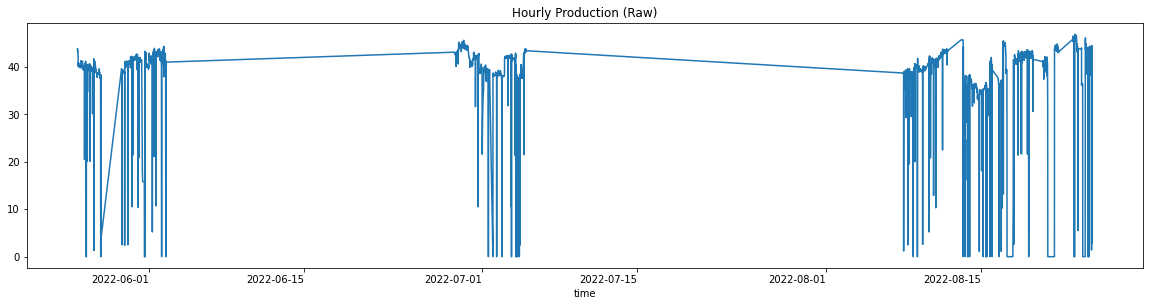

In [9]:
plt.figure(figsize=(20, 5)) 
df['Hourly Production'].plot()
plt.title('Hourly Production (Raw)')
plt.xticks(rotation=0)
plt.show()
# 正常產出應該要在40上下，Target有許多異常狀態，須砍掉異常sample

In [10]:
# Target異常狀態處理
df = df[(df['Hourly Production'] > 30)]
df.shape
# 刪除903(17668 - 16765)個樣本

(32731, 28)

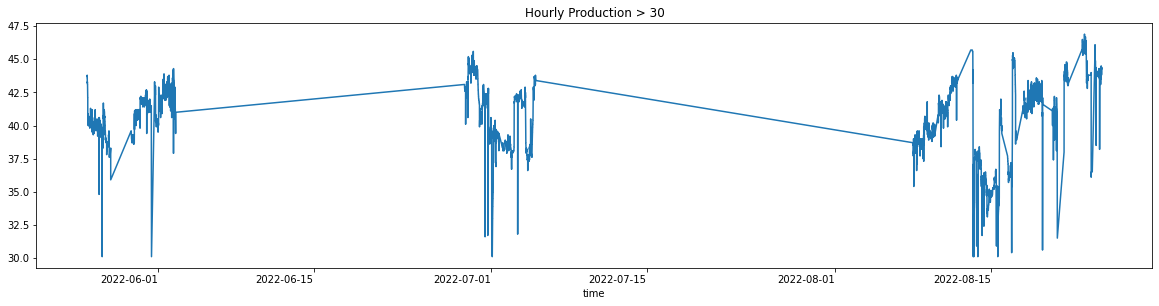

In [11]:
plt.figure(figsize=(20, 5)) 
df['Hourly Production'].plot()
plt.title('Hourly Production > 30')
plt.xticks(rotation=0)
plt.show()

#### Correlation

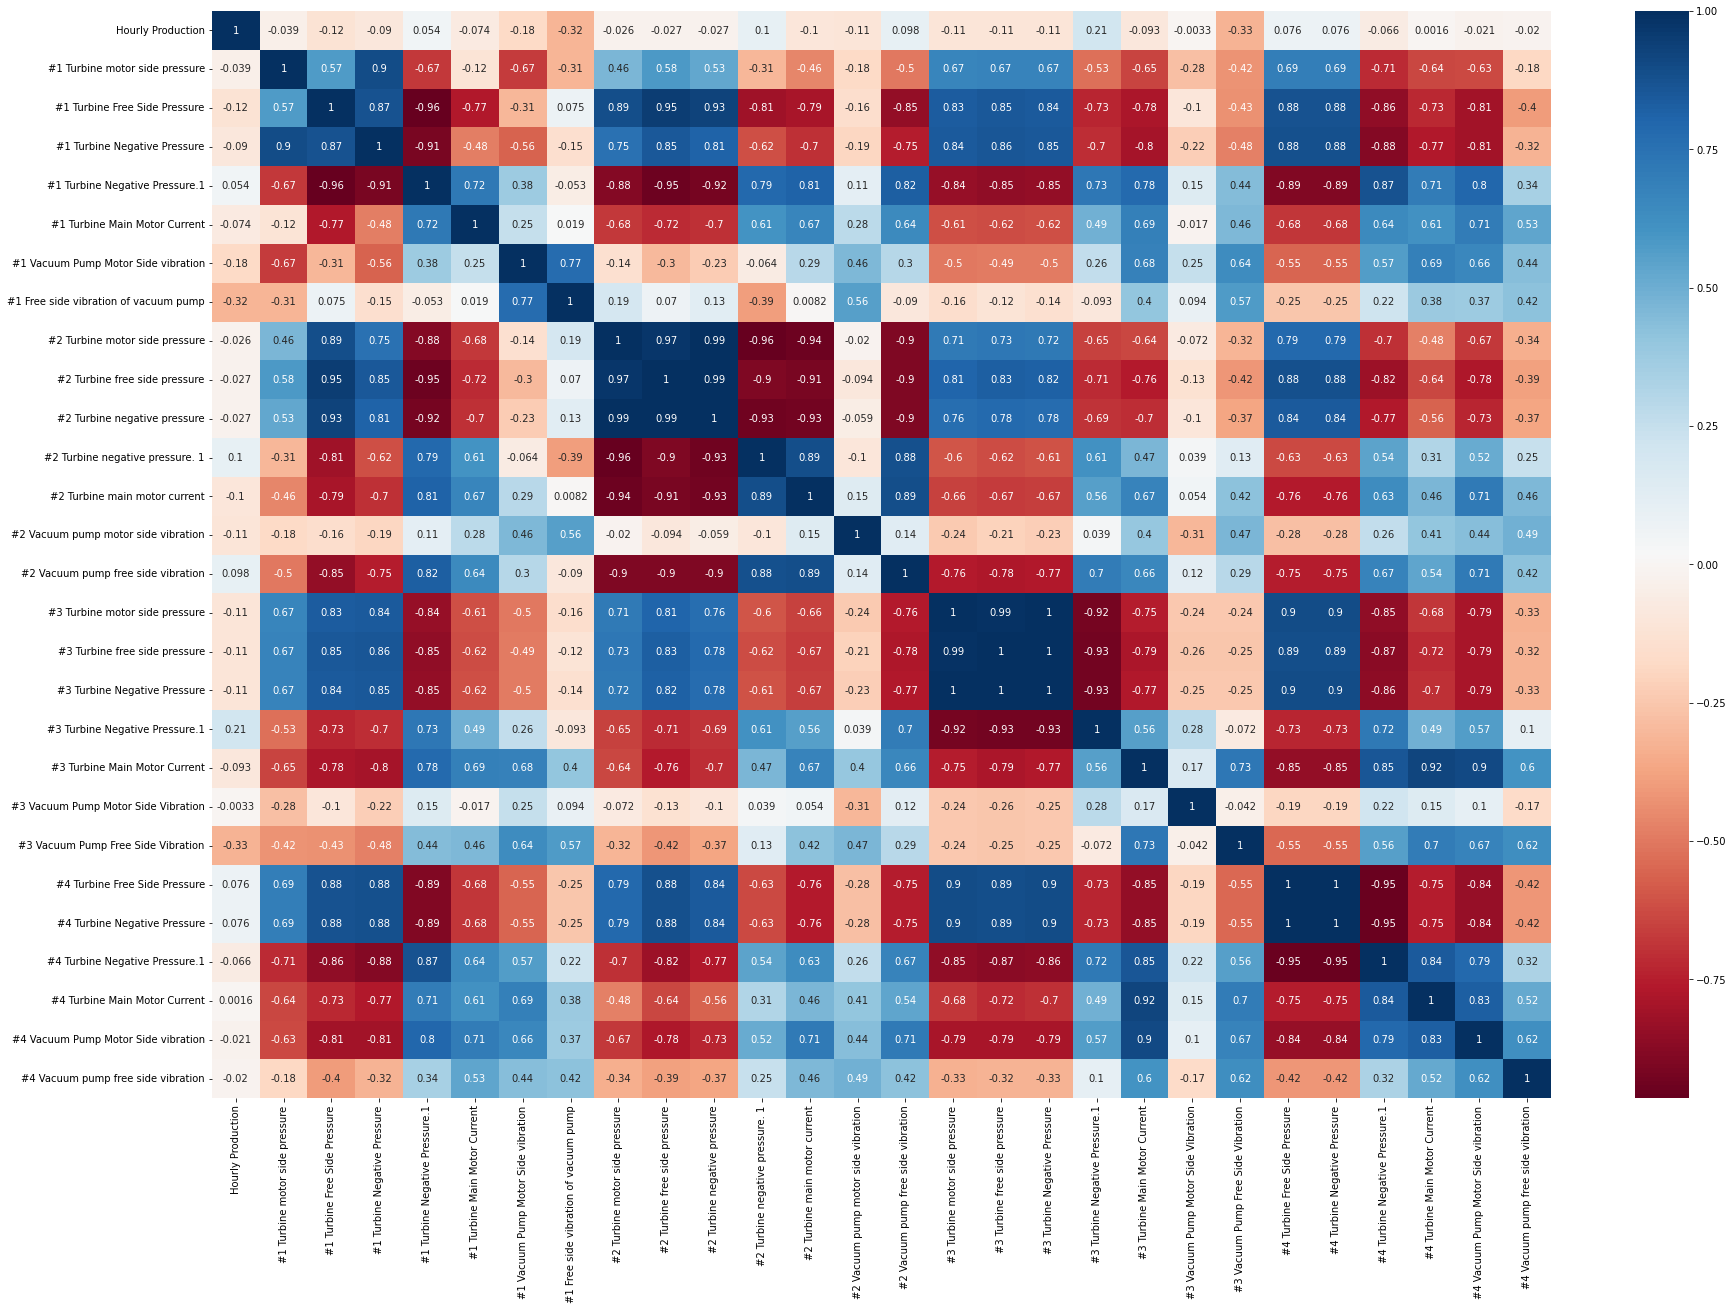

In [12]:
plt.figure(figsize=(30, 20))
sns.heatmap(data = df.corr(), annot=True, cmap = 'RdBu')
plt.show()

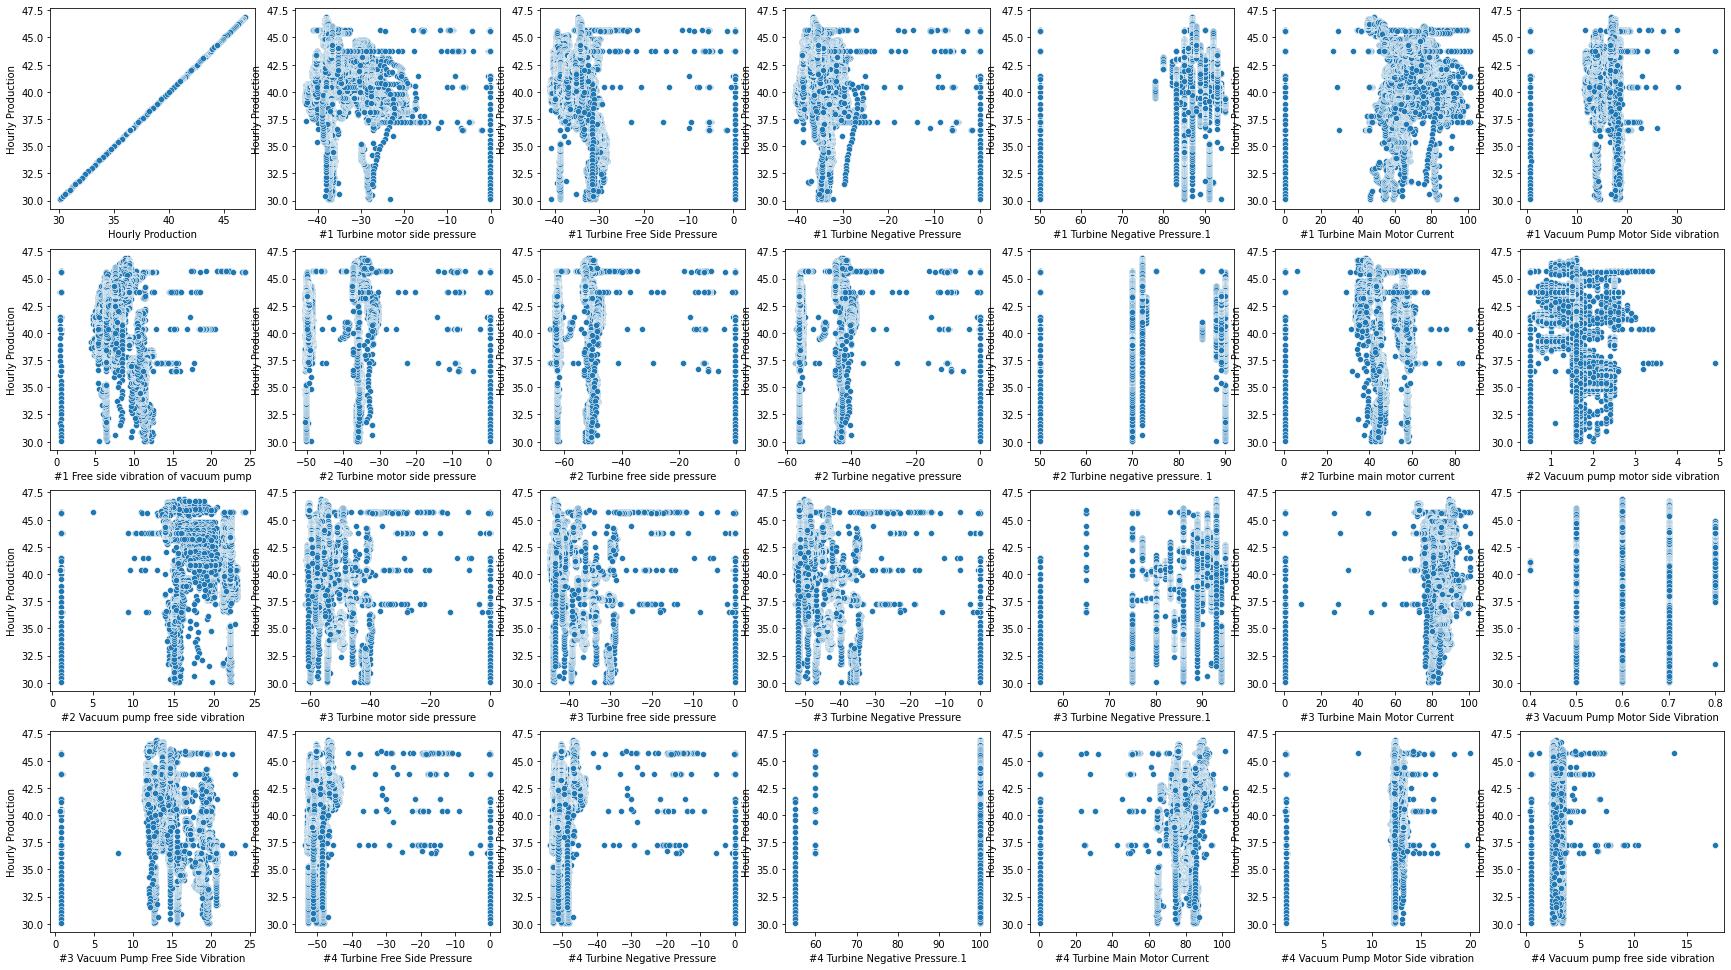

In [13]:
# "Relationship between features and target"
a, b = 4, 7
k = 0
fig, ax = plt.subplots(a, b, figsize = (30, 17))
for i in range(a):
    for j in range(b):
        sns.scatterplot(x = df.columns[k], y = target, data = df, ax = ax[i, j])
        k += 1
plt.show()


#### Split train、test data

In [14]:
train, test = train_test_split(df, test_size = 0.2, shuffle = shuffle)
print(f"train shape: {train.shape} 、 test shape: {test.shape}")

train shape: (26184, 28) 、 test shape: (6547, 28)


#### Feature Analysis

In [15]:
train1, test1 = train.copy(), test.copy()
train1, valid1 = train_test_split(train1, test_size = 0.2, shuffle = shuffle)
train1, valid1, test1 = train1.sort_index(), valid1.sort_index(), test1.sort_index()
print(train1.shape, valid1.shape, test1.shape)

(20947, 28) (5237, 28) (6547, 28)


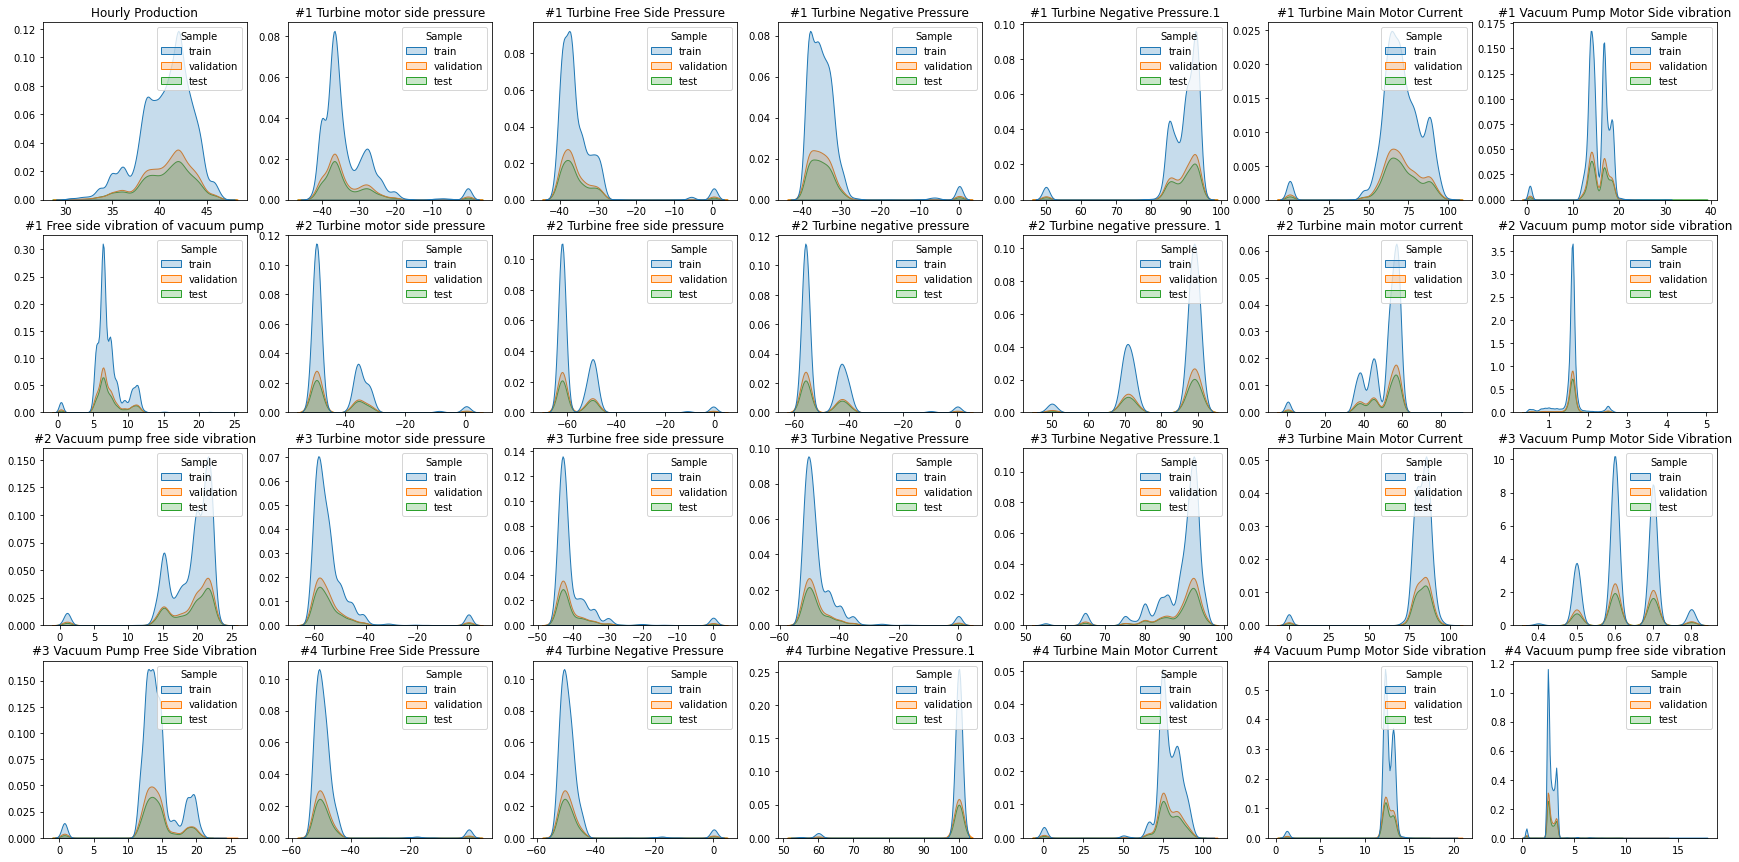

In [16]:
train2, valid2, test2 = train1.copy(), test1.copy(), valid1.copy()
train2["Sample"], valid2["Sample"], test2["Sample"] = "train", "validation", "test"
data = pd.concat([train2, valid2, test2])

a, b = 4, 7
k = 0
fig, ax = plt.subplots(a, b, figsize = (30, 15))
for i in range(a):
    for j in range(b):
        sns.kdeplot(data = data, x = data.columns[k], hue = "Sample", shade=True, ax = ax[i, j])
        ax[i, j].set(ylabel = None, xlabel = None, title = data.columns[k])
        k += 1
fig.savefig("chart/image/feat_kde.svg")

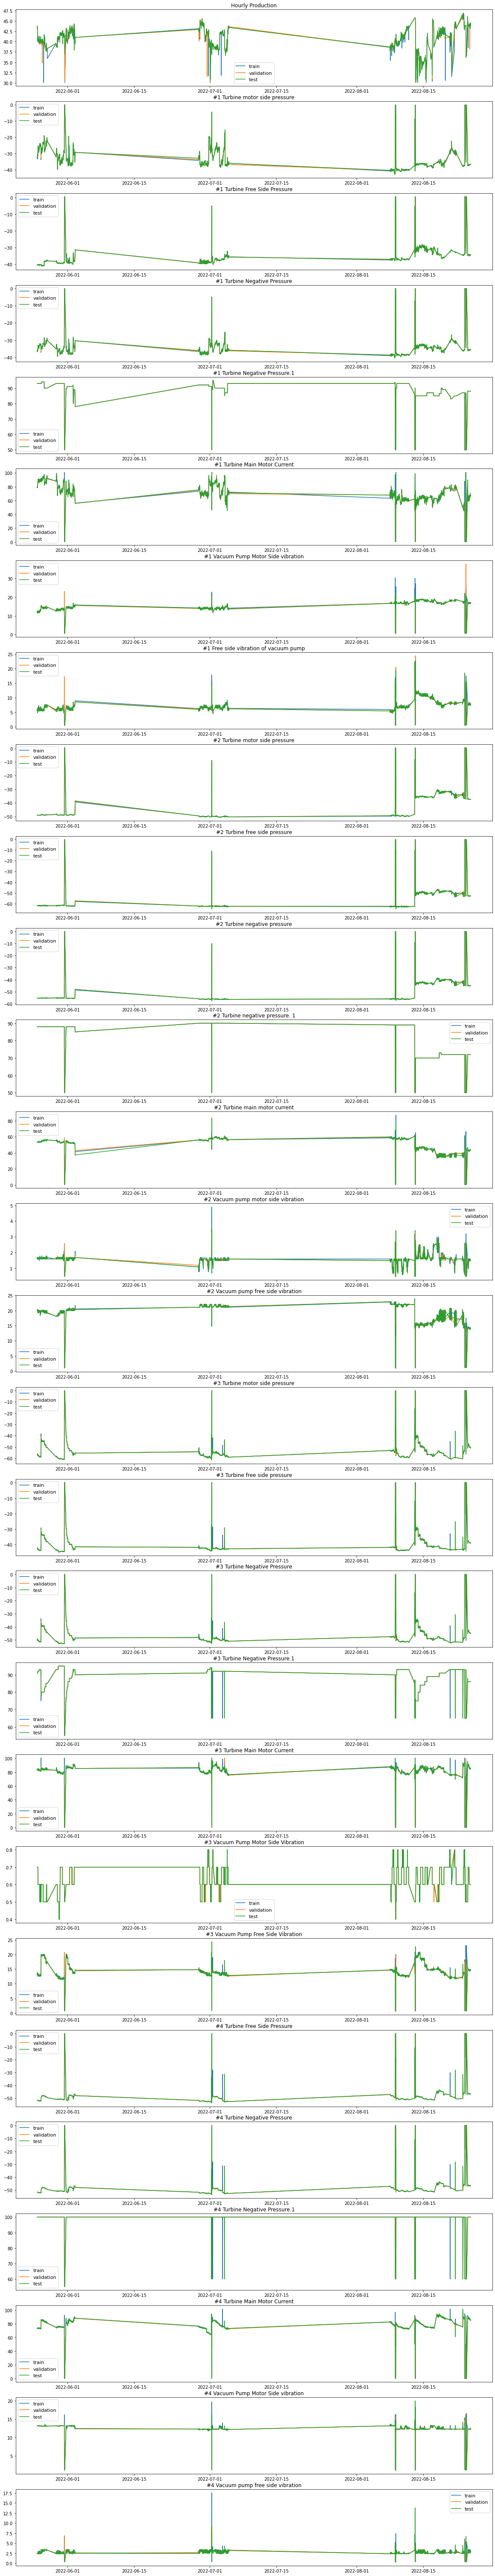

In [17]:
a, b = len(train1.columns), 1
k = 0
fig, ax = plt.subplots(a, b, figsize = (20, 110))
for i in range(a):
    ax[i].plot(train1[train1.columns[k]])
    ax[i].plot(valid1[valid1.columns[k]])
    ax[i].plot(test1[test1.columns[k]])
    ax[i].set_title(train1.columns[k])
    ax[i].legend(["train", "validation", "test"], fontsize = 11) 
    k += 1
fig.savefig("chart/image/feat_line.svg")

#### Outlier

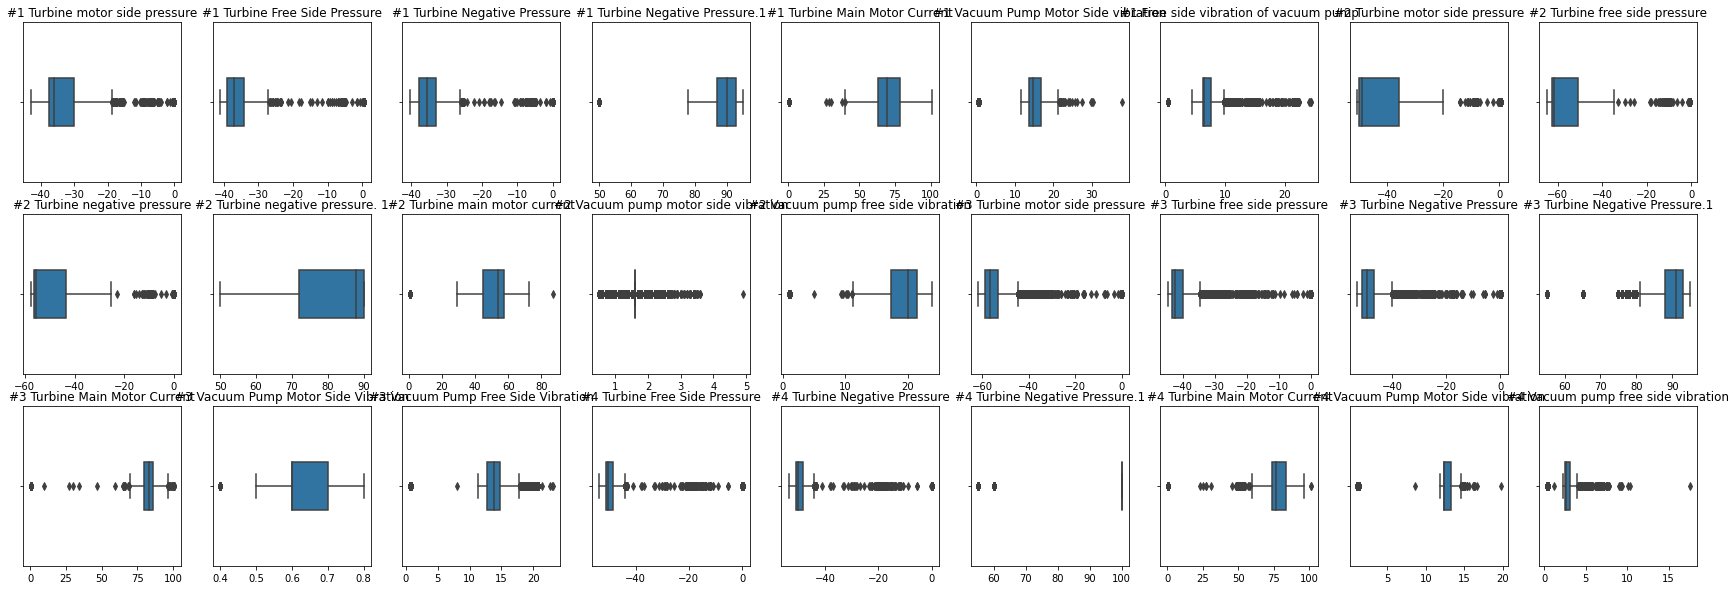

In [18]:
a, b = 3, 9
k = 0
fig, ax = plt.subplots(a, b, figsize = (30, 10))
for i in range(a):
    for j in range(b):
        # train1, test1 = train[[features[k]]], test[[features[k]]]
        # train1["flag"], test1["flag"] = "train", "test"
        # data = pd.concat([train1, test1])
        # sns.boxplot(x = "flag", y = features[k], data = data, width = 0.5, ax = ax[i, j])

        sns.boxplot(x = features[k], data = train, width = 0.3, ax = ax[i, j])
        ax[i, j].set(xlabel = None, ylabel = None, title = features[k])
        k += 1

In [19]:
outlier_boundary = {}
for col in features:
    Q1   = train[col].quantile(0.25)
    Q3   = train[col].quantile(0.75)
    IQR  = Q3 - Q1
    min_ = Q1 - (1.5 * IQR)
    max_ = Q3 + (1.5 * IQR)
    
    train[col] = train[col].apply(lambda X: max_ if X > max_ else X)
    train[col] = train[col].apply(lambda X: min_ if X < min_ else X)

    test[col] = test[col].apply(lambda X: max_ if X > max_ else X)
    test[col] = test[col].apply(lambda X: min_ if X < min_ else X)

    outlier_boundary[col] = {
        "min": min_,
        "max": max_,
    }

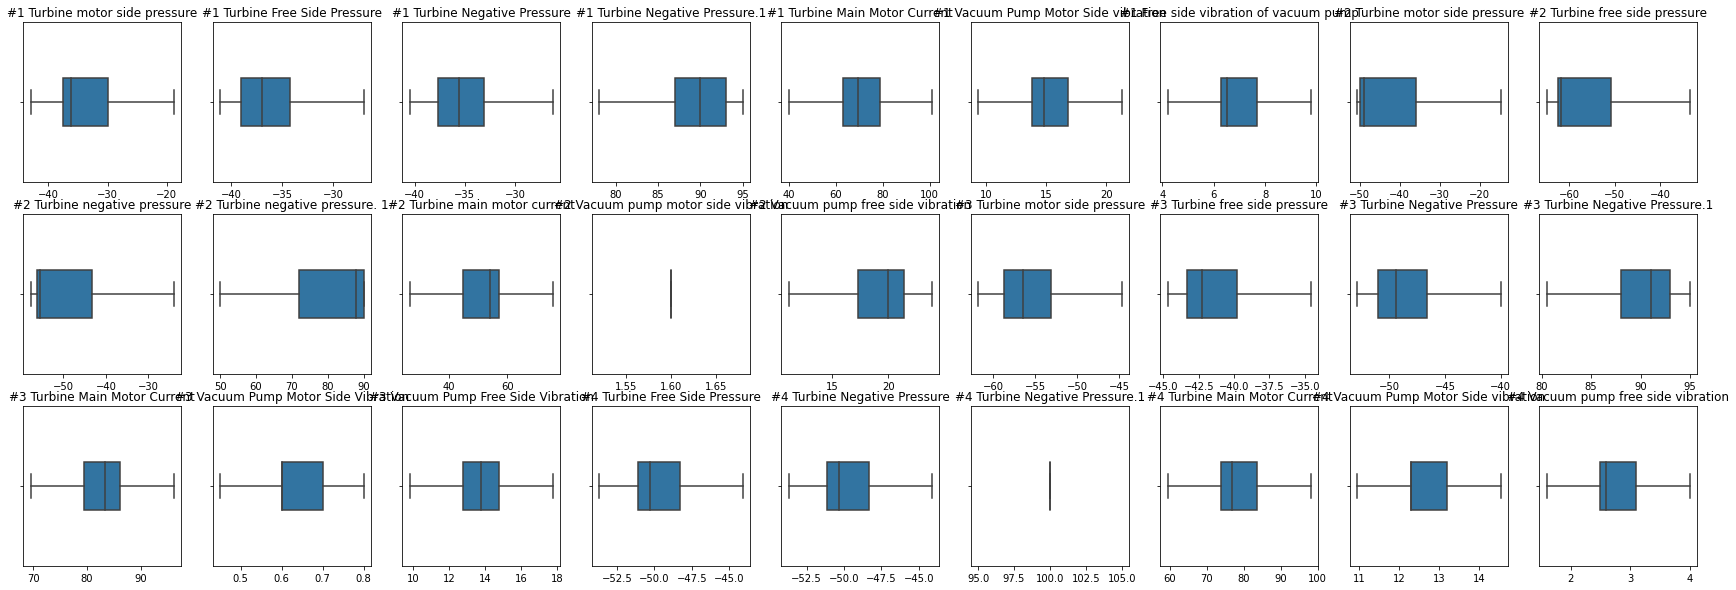

In [20]:
a, b = 3, 9
k = 0
fig, ax = plt.subplots(a, b, figsize = (30, 10))
for i in range(a):
    for j in range(b):
        # train1, test1 = train[[features[k]]], test[[features[k]]]
        # train1["flag"], test1["flag"] = "train", "test"
        # data = pd.concat([train1, test1])
        # sns.boxplot(x = "flag", y = features[k], data = data, width = 0.5, ax = ax[i, j])

        sns.boxplot(x = features[k], data = train, width = 0.3, ax = ax[i, j])
        ax[i, j].set(xlabel = None, ylabel = None, title = features[k])
        k += 1

In [21]:
train.to_csv("data/preprocess.csv", index = False)

#### Skew

In [22]:
skewness = train[features].apply(lambda X: skew(X)).sort_values(ascending=False)
skewness = pd.DataFrame({'Feature' : skewness.index, 'Skew' : skewness.values})
skewness = skewness.query("(Skew > 0.75) | (Skew < -0.75)")
skewness = skewness.reset_index(drop = True)
skewness

,Feature,Skew
0,#2 Turbine free side pressure,1.439789
1,#2 Turbine negative pressure,1.429986
2,#2 Turbine motor side pressure,1.403802
3,#3 Turbine free side pressure,1.132954
4,#3 Turbine Negative Pressure,1.012253
5,#1 Turbine motor side pressure,1.011366
6,#3 Turbine motor side pressure,0.921503
7,#1 Turbine Free Side Pressure,0.914232
8,#1 Turbine Negative Pressure,0.846925
9,#4 Turbine Negative Pressure,0.762235


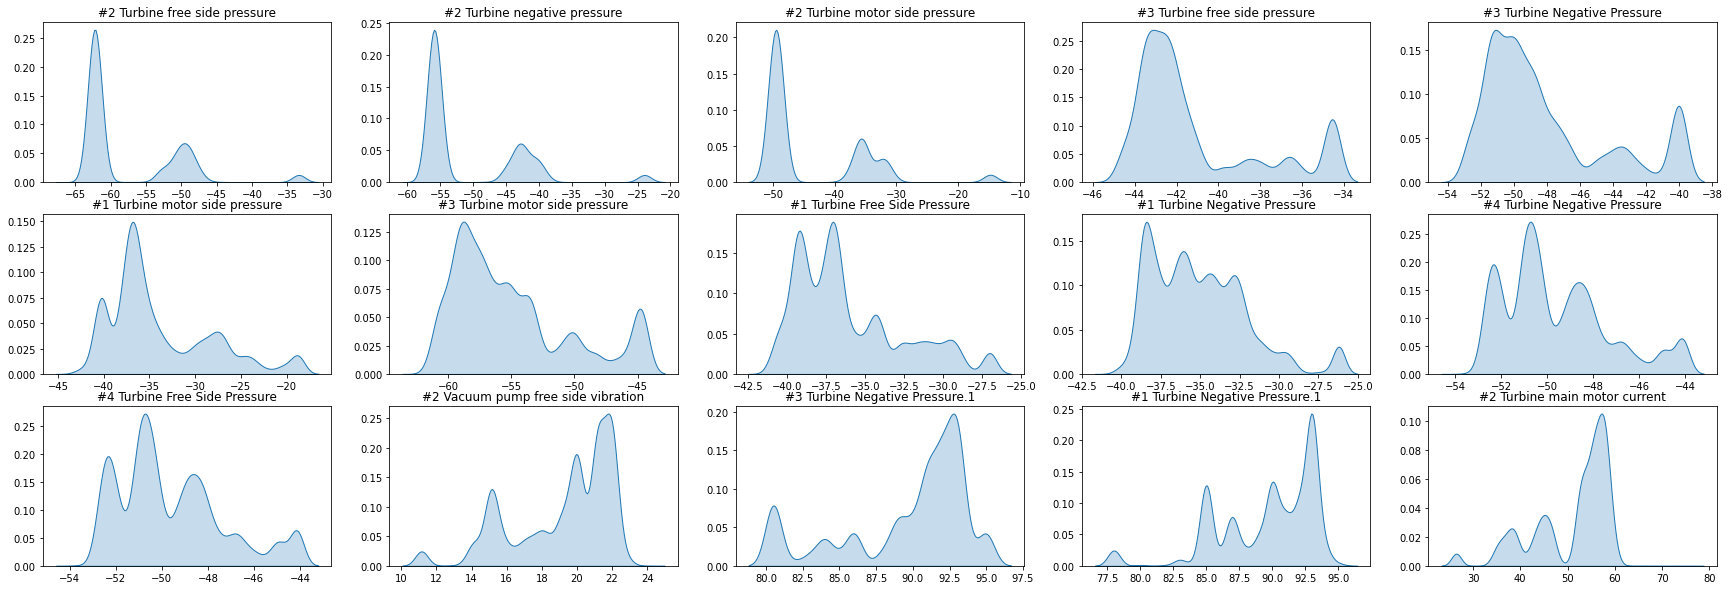

In [23]:
a, b = 3, 5
k = 0
fig, ax = plt.subplots(a, b, figsize = (30, 10))
for i in range(a):
    for j in range(b):
        sns.kdeplot(data = train, x = skewness["Feature"].iloc[k], shade=True, ax = ax[i, j])
        ax[i, j].set(ylabel = None, xlabel = None, title = skewness["Feature"].iloc[k])
        k += 1

In [24]:
pt = PowerTransformer(method = 'yeo-johnson')
train[skewness["Feature"]] = pt.fit_transform(train[skewness["Feature"]])

In [25]:
test[skewness["Feature"]] = pt.transform(test[skewness["Feature"]])

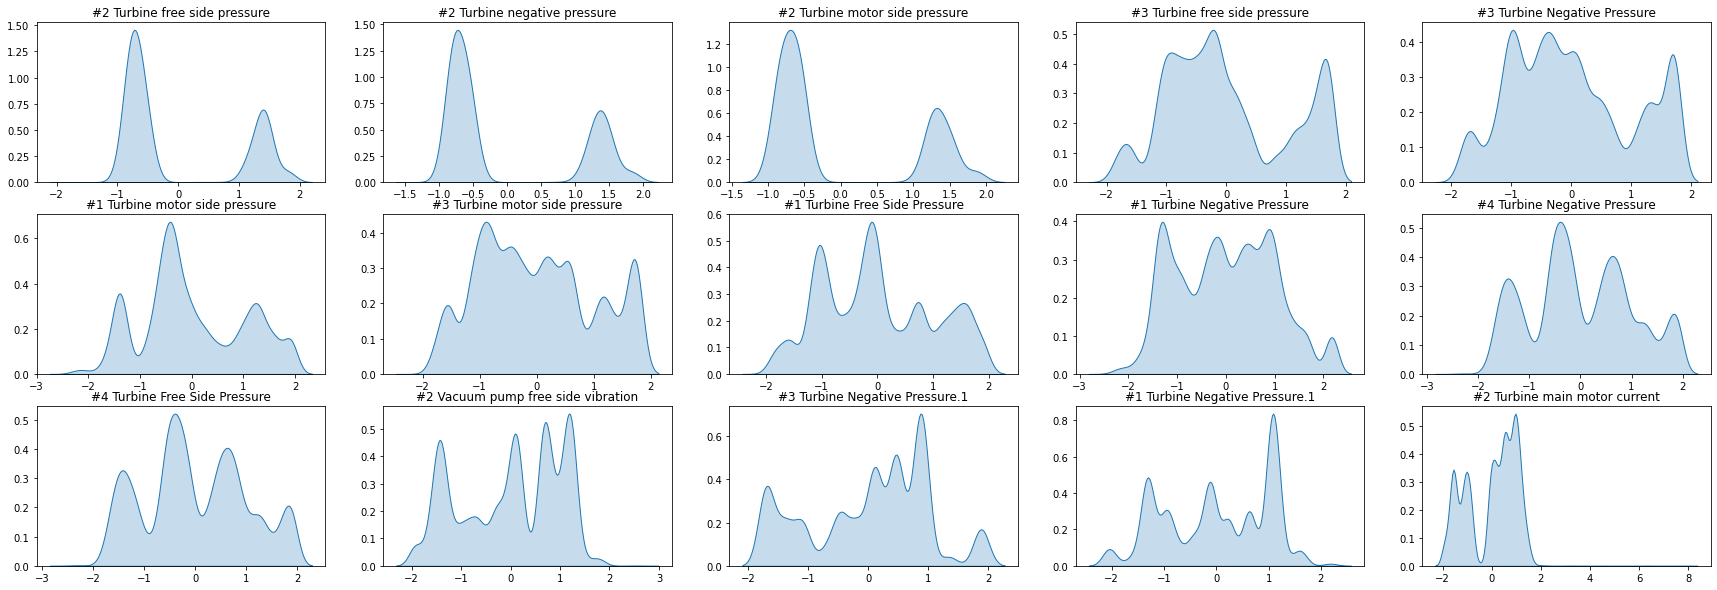

In [26]:
a, b = 3, 5
k = 0
fig, ax = plt.subplots(a, b, figsize = (30, 10))
for i in range(a):
    for j in range(b):
        sns.kdeplot(data = train, x = skewness["Feature"].iloc[k], shade=True, ax = ax[i, j])
        ax[i, j].set(ylabel = None, xlabel = None, title = skewness["Feature"].iloc[k])
        k += 1

#### Scaling

In [27]:
scaler = StandardScaler()
train[features] = scaler.fit_transform(train[features])

In [28]:
test[features] = scaler.transform(test[features])

## Modeling

#### Split data

In [29]:
train_data, test_data = train, test
train_data, valid_data = train_test_split(train_data, test_size = 0.2, shuffle = shuffle)
print(train_data.shape, valid_data.shape, test_data.shape)

(20947, 28) (5237, 28) (6547, 28)


#### Select device

In [30]:
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# print(device)

#### Data transform to Torch Dataset

In [31]:
class Dataset_transform(Dataset):
    def __init__(self, df, features, target):
        self.n_samples = len(df)
        self.X = torch.Tensor(df[features].values)#.to(device)
        self.y = torch.Tensor(df[target].values.reshape(-1, 1))#.to(device)
                                            
    def __len__(self):
        return self.n_samples

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [32]:
train_dataset = Dataset_transform(train_data, features, target)
valid_dataset = Dataset_transform(valid_data, features, target)
test_dataset = Dataset_transform(test_data, features, target)

#### DataLoader to use for batch

In [33]:
batch_size = 128
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = shuffle)
valid_dataloader = DataLoader(valid_dataset, batch_size = len(valid_dataset))
test_dataloader = DataLoader(test_dataset, batch_size = len(test_dataset))

#### Model structure

In [34]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.net  = nn.Sequential(
            nn.Linear(27, 32),
            nn.LeakyReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 32),
            nn.LeakyReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 1),
        )
    
    def forward(self, x):
        x = self.net(x)
        return x

In [35]:
epochs = 1000
model = Model()#.to(device)
criterion = nn.MSELoss()#.to(device)
optimizer = optim.Adam(model.parameters(), lr = 0.0001)

#### Initialize weights

In [36]:
# 初始化權重，使其符合常態分布
for m in model.modules():
    if isinstance(m, (nn.Linear)):
        nn.init.kaiming_normal_(m.weight)

#### Training model

In [37]:
# validate、test預測後的損失函數，以及相關分數
def eval(dataloader, model, criterion, mode = "eval"):
    losses = 0
    pred1, y1 = torch.Tensor([]), torch.Tensor([])
    for batch, (X, y) in enumerate(dataloader):
        pred = model(X) #預測
        loss = criterion(pred, y) #計算損失函數
        losses += loss.item()

        # pred, y = pred.cpu(), y.cpu()
        pred1 = torch.concat([pred1, pred])
        y1 = torch.concat([y1, y])

    losses /= (batch + 1)

    if mode == "train":
        return losses
        
    pred1 = pred1.detach().numpy()
    y1 = y1.detach().numpy()
    MSE = mean_squared_error(pred1, y1)
    RMSE = MSE ** (1/2)
    MAPE = mean_absolute_percentage_error(pred1, y1)
    R2 = r2_score(pred1, y1)
    
    return MSE, RMSE, MAPE, R2, pred1, y1

In [38]:
# 建模
best_loss = np.inf
paitence = 30
train_losses = []
valid_losses = []
for epoch in range(epochs):
    train_loss = 0
    valid_loss = 0
    # train model
    model.train() # 模型為訓練模式
    for batch, (X_train, y_train) in enumerate(train_dataloader):
        train_pred = model(X_train) #預測
        loss = criterion(train_pred, y_train) #計算損失函數

        optimizer.zero_grad() # 梯度在反向傳播前先清零
        loss.backward() # 反向傳播，計算權重對損失函數的梯度
        optimizer.step()  # 根據梯度更新權重
        train_loss += loss.item()
    train_loss /= (batch + 1)
    train_losses.append(train_loss)

    # validate model
    model.eval()# 模型為評估模式
    valid_loss = eval(valid_dataloader, model, criterion, mode = "train")
    valid_losses.append(valid_loss)

    print(f"Epoch {epoch} - train_loss: {train_loss:.4f},  valid_loss: {valid_loss:.4f}")

    # 損失函數連續30個epoches都沒下降的話就終止訓練
    if valid_loss < best_loss:
        best_loss = valid_loss
        remain_patience = paitence
    else:
        remain_patience -= 1
        if remain_patience == 0:
            print('early stop!')
            break
print("Done!")

Epoch 0 - train_loss: 1652.1128,  valid_loss: 1647.1273
Epoch 1 - train_loss: 1640.0755,  valid_loss: 1634.3483
Epoch 2 - train_loss: 1625.8301,  valid_loss: 1615.0625
Epoch 3 - train_loss: 1609.1339,  valid_loss: 1598.6746
Epoch 4 - train_loss: 1589.7166,  valid_loss: 1587.2008
Epoch 5 - train_loss: 1567.6988,  valid_loss: 1555.1191
Epoch 6 - train_loss: 1543.4010,  valid_loss: 1524.0244
Epoch 7 - train_loss: 1516.6434,  valid_loss: 1502.3412
Epoch 8 - train_loss: 1488.0404,  valid_loss: 1475.8749
Epoch 9 - train_loss: 1457.3894,  valid_loss: 1448.7246
Epoch 10 - train_loss: 1425.0254,  valid_loss: 1412.5443
Epoch 11 - train_loss: 1390.9478,  valid_loss: 1372.5543
Epoch 12 - train_loss: 1355.7903,  valid_loss: 1337.7305
Epoch 13 - train_loss: 1319.2636,  valid_loss: 1299.4680
Epoch 14 - train_loss: 1281.5067,  valid_loss: 1257.5338
Epoch 15 - train_loss: 1243.0806,  valid_loss: 1226.7522
Epoch 16 - train_loss: 1203.6925,  valid_loss: 1185.8268
Epoch 17 - train_loss: 1163.7042,  valid_

#### Predict

In [39]:
data_name = ["Train", "Validation", "Test"]
dataloaders = [train_dataloader, valid_dataloader, test_dataloader]
score = pd.DataFrame(columns = ["MSE", "RMSE", "MAPE", "R2"])
result = {}

for name, dataloader in zip(data_name, dataloaders):
    MSE, RMSE, MAPE, R2, pred, true = eval(dataloader, model, criterion)
    score.loc[name] = [MSE, RMSE, MAPE, R2]
    result[name] = {
        "true": true.reshape(-1),
        "pred": pred.reshape(-1),
    }

train_result = pd.DataFrame(result["Train"])
valid_result = pd.DataFrame(result["Validation"])
test_result = pd.DataFrame(result["Test"])
score.round(4)

,MSE,RMSE,MAPE,R2
Train,0.6258,0.7910,0.0106,0.9042
Validation,0.6951,0.8337,0.0111,0.8946
Test,0.6694,0.8181,0.0111,0.8963


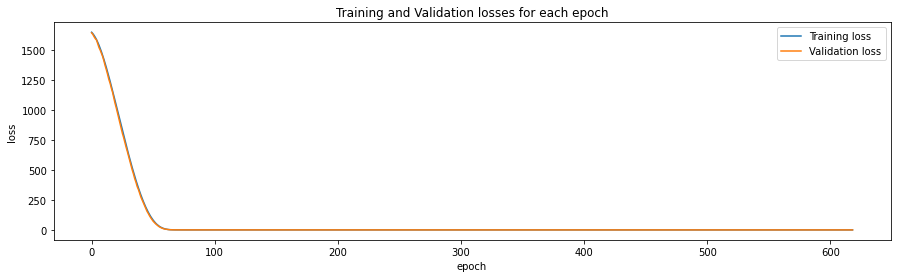

In [40]:
plt.figure(figsize=(15, 4))
plt.plot(train_losses, label='Training loss')
plt.plot(valid_losses, label='Validation loss')
plt.title("Training and Validation losses for each epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.savefig("chart/image/loss.svg")

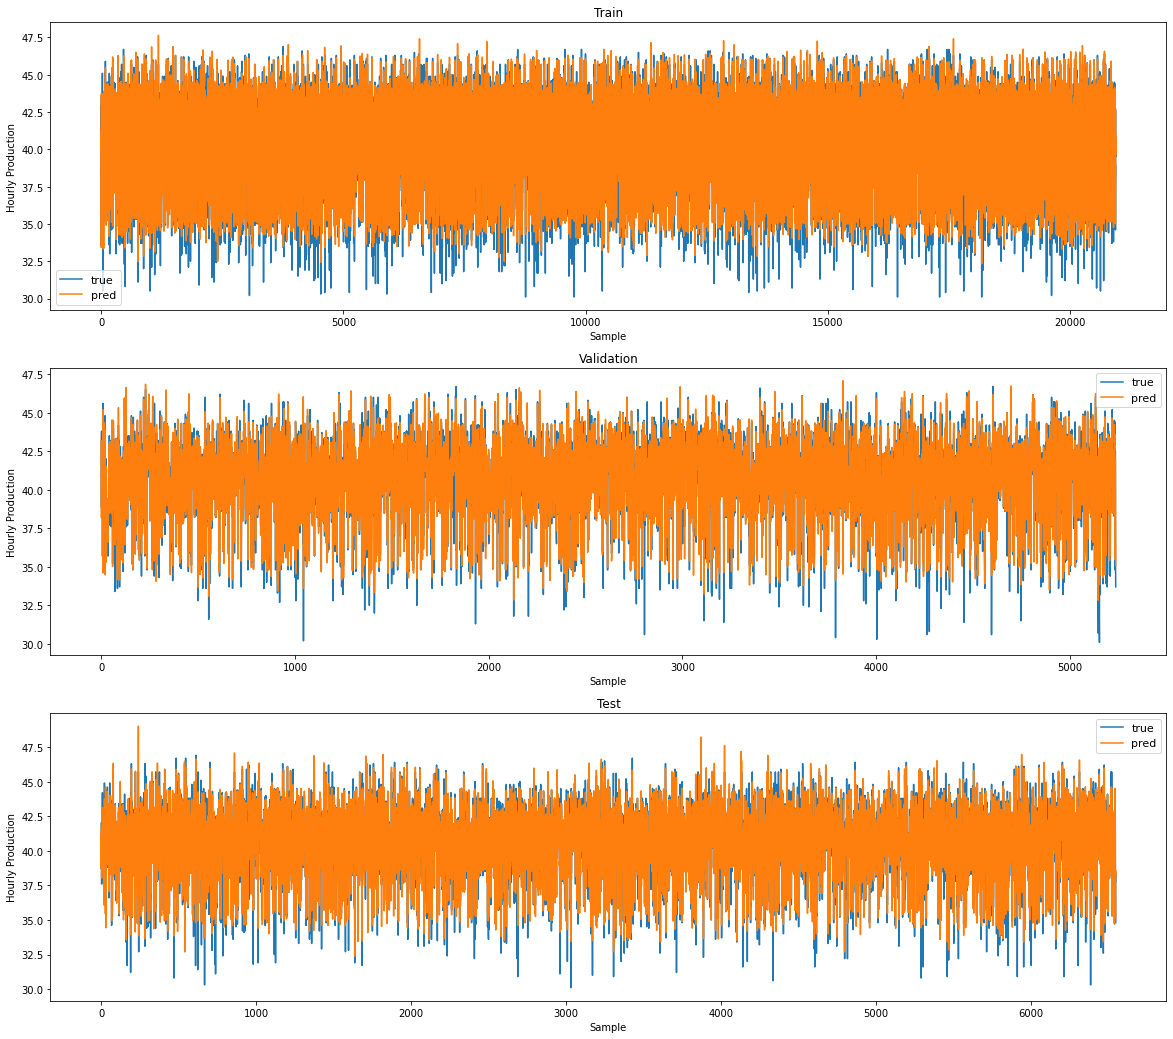

In [41]:
data = [train_result, valid_result, test_result]
a, b = len(data), 1
k = 0
fig, ax = plt.subplots(a, b, figsize = (20, 18))
for i in range(a):
    ax[i].plot(data[i])
    ax[i].set(ylabel = "Hourly Production", xlabel = "Sample", title = data_name[i])
    ax[i].legend(["true", "pred"], fontsize = 11) 
    k += 1
fig.savefig("chart/image/pred.svg")

## Save

In [42]:
# 儲存model
pickle.dump(features, open('model/feat_order.pkl','wb'))
skew_feat = [list(train.columns[1:]).index(skewness["Feature"][i]) for i in range(len(skewness["Feature"]))]
pickle.dump(skew_feat, open('model/skew_feat.pkl','wb'))
pickle.dump(outlier_boundary, open('model/outlier_boundary.pkl','wb'))
pickle.dump(pt, open('model/power_tf.pkl','wb'))
pickle.dump(scaler, open('model/scaler.pkl','wb'))
torch.save(model.state_dict(), "model/nn_weights.pt") # 儲存權重

In [43]:
# 抓出產出超過40的sample的所有feature之四分位數
df1 = pd.read_csv("data/preprocess.csv")
df40 = df1[(df1["Hourly Production"] >= 40)][features]
df40_range = df40.describe().T[["25%", "50%", "75%"]]
df40_range = df40_range.reset_index()
df40_range = df40_range.rename(columns = {"index": "feature"})
df40_range.to_csv("model/output40.csv", index = False)

## Input X optimize

#### Load model

In [45]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.net  = nn.Sequential(
            nn.Linear(27, 32),
            nn.LeakyReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 32),
            nn.LeakyReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 1),
        )
    
    def forward(self, x):
        x = self.net(x)
        return x

In [46]:
# 載入訓練好的模型
features = pickle.load(open('model/feat_order.pkl','rb'))
skew_feat = pickle.load(open('model/skew_feat.pkl','rb'))
pt = pickle.load(open('model/power_tf.pkl','rb'))
scaler = pickle.load(open('model/scaler.pkl','rb'))

model = Model()
model.load_state_dict(torch.load("model/nn_weights.pt")) # 更該model權重
model.eval()

Model(
  (net): Sequential(
    (0): Linear(in_features=27, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

#### Input X

In [47]:
import random

# 輸入參數
df0 = pd.read_csv("data/data.csv")
features = df0.columns[5:].to_list()
df_lower40 = df0[(df0["Hourly Production"] < 40)]["Hourly Production"]
ind = random.choice(df_lower40.index)
output = df0.loc[ind, "Hourly Production"]
X0 = df0.iloc[ind: ind+1][features]

# 指定不可調動的參數
fixed_mask = [random.randint(0, 1) for i in range(27)]

print("initial X =", X0.values)
print("fixed mask =", fixed_mask)

initial X = [[-0.2  0.4  0.1 50.   0.3  0.6  0.5  0.4 -0.4  0.  50.   0.4  0.5  1.
  -0.1  0.1 -0.  65.   0.1  0.5  0.7  0.1  0.1 60.   0.3  1.2  0.4]]
fixed mask = [1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0]


In [48]:
input_X = {X0.columns[i]: X0.values[0][i] for i in range(X0.shape[1])}
fixed_mask = {X0.columns[i]: random.randint(0, 1) for i in range(X0.shape[1])}

input_X = pd.DataFrame(input_X, index = [0])
fixed_mask = pd.DataFrame(fixed_mask, index = [0])

input_X = input_X[features]
fixed_mask = fixed_mask[features]

fixed_mask = fixed_mask.values[0]

In [49]:
# 產出超過40的sample的所有freature之四分位數
df40_range = pd.read_csv("model/output40.csv")
df40_range.head(3)

,feature,25%,50%,75%
0,#1 Turbine motor side pressure,-37.4,-35.7,-32.1
1,#1 Turbine Free Side Pressure,-39.2,-37.2,-34.6
2,#1 Turbine Negative Pressure,-37.8,-36.2,-34.6


#### Check X is in distribution range

In [50]:
init_X = input_X.values.copy()

In [51]:
# 查看輸入的參數是否在25% ~ 75%之間
for i, x in enumerate(init_X[0]):
    if (x < df40_range.iloc[i, 1]) or (x > df40_range.iloc[i, 3]):
        if (fixed_mask[i] == 0):
            print(f"{i} : ({round(float(x), 4)}) not in {df40_range.iloc[i, 1].round(4)} ~ {df40_range.iloc[i, 3].round(4)}")
        else:
            print(f"{i} : ({round(float(x), 4)}) not in {df40_range.iloc[i, 1].round(4)} ~ {df40_range.iloc[i, 3].round(4)},  but parameter is fixed.")

0 : (-0.2) not in -37.4 ~ -32.1,  but parameter is fixed.
1 : (0.4) not in -39.2 ~ -34.6
2 : (0.1) not in -37.8 ~ -34.6,  but parameter is fixed.
3 : (50.0) not in 88.0 ~ 93.0,  but parameter is fixed.
4 : (0.3) not in 63.1 ~ 77.1
5 : (0.6) not in 13.7 ~ 16.7
6 : (0.5) not in 6.3 ~ 7.5,  but parameter is fixed.
7 : (0.4) not in -49.8 ~ -36.1
8 : (-0.4) not in -62.4 ~ -52.0,  but parameter is fixed.
9 : (0.0) not in -56.2 ~ -44.0,  but parameter is fixed.
10 : (50.0) not in 72.0 ~ 89.0
11 : (0.4) not in 42.6 ~ 56.1,  but parameter is fixed.
12 : (0.5) not in 1.6 ~ 1.6,  but parameter is fixed.
13 : (1.0) not in 18.1 ~ 21.2,  but parameter is fixed.
14 : (-0.1) not in -59.1 ~ -54.7
15 : (0.1) not in -43.4 ~ -41.4,  but parameter is fixed.
16 : (-0.0) not in -51.3 ~ -48.3
17 : (65.0) not in 89.0 ~ 93.0
18 : (0.1) not in 78.5 ~ 85.8
19 : (0.5) not in 0.6 ~ 0.7
20 : (0.7) not in 12.7 ~ 14.7
21 : (0.1) not in -51.6 ~ -47.7
22 : (0.1) not in -51.6 ~ -47.7
23 : (60.0) not in 100.0 ~ 100.0
24 :

In [52]:
# 如果輸入的參數不在25% ~ 75%之間，就用中位數取代
print("init X:", init_X)
for j, x in enumerate(init_X[0]):
    if ((x < df40_range.iloc[j, 1]) or (x > df40_range.iloc[j, 3])) and (fixed_mask[j] == 0):
        init_X[0][j] = df40_range.iloc[j, 2]
print("new X:", init_X)

init X: [[-0.2  0.4  0.1 50.   0.3  0.6  0.5  0.4 -0.4  0.  50.   0.4  0.5  1.
  -0.1  0.1 -0.  65.   0.1  0.5  0.7  0.1  0.1 60.   0.3  1.2  0.4]]
new X: [[ -0.2 -37.2   0.1  50.   70.1  14.6   0.5 -49.   -0.4   0.   88.    0.4
    0.5   1.  -57.5   0.1 -50.   91.   81.5   0.6  13.6 -50.6 -50.6 100.
    0.3  12.4   0.4]]


In [53]:
# 查看輸入的參數是否在25% ~ 75%之間
for i, x in enumerate(init_X[0]):
    if (x < df40_range.iloc[i, 1]) or (x > df40_range.iloc[i, 3]):
        if (fixed_mask[i] == 0):
            print(f"{i} : ({round(float(x), 4)}) not in {df40_range.iloc[i, 1].round(4)} ~ {df40_range.iloc[i, 3].round(4)}")
        else:
            print(f"{i} : ({round(float(x), 4)}) not in {df40_range.iloc[i, 1].round(4)} ~ {df40_range.iloc[i, 3].round(4)},  but parameter is fixed.")

0 : (-0.2) not in -37.4 ~ -32.1,  but parameter is fixed.
2 : (0.1) not in -37.8 ~ -34.6,  but parameter is fixed.
3 : (50.0) not in 88.0 ~ 93.0,  but parameter is fixed.
6 : (0.5) not in 6.3 ~ 7.5,  but parameter is fixed.
8 : (-0.4) not in -62.4 ~ -52.0,  but parameter is fixed.
9 : (0.0) not in -56.2 ~ -44.0,  but parameter is fixed.
11 : (0.4) not in 42.6 ~ 56.1,  but parameter is fixed.
12 : (0.5) not in 1.6 ~ 1.6,  but parameter is fixed.
13 : (1.0) not in 18.1 ~ 21.2,  but parameter is fixed.
15 : (0.1) not in -43.4 ~ -41.4,  but parameter is fixed.
24 : (0.3) not in 73.6 ~ 85.2,  but parameter is fixed.
26 : (0.4) not in 2.5 ~ 3.0,  but parameter is fixed.


#### Initial prediction to see if gradient optimization is needed

In [54]:
def transform(X):
    X[0, skew_feat] = pt.transform(X[0, skew_feat].reshape(1, -1)) # 偏態轉換
    X[0] = scaler.transform(X[0].reshape(1, -1)) # 標準化轉換
    X = torch.Tensor(X)
    return X

In [55]:
# 如果參數調成中位數就已經滿足產出>=target，直接返回參數。
# 如果參數調整後預測值仍無法藉於0~50，此輪的input不可用，可減少fixed mask的數量
target = 41

X = init_X.copy()
X = transform(X)
print("initial X =", X0.values)
print("transform X =", X)

init_pred = model(X).item()

print("output =", output)
print("Predict =", init_pred)
if (init_pred < 30) or (init_pred > 50):
    print("Unable to optimize X.")
elif (init_pred > target):
    print("Meet target after updating X to medium")

initial X = [[-0.2  0.4  0.1 50.   0.3  0.6  0.5  0.4 -0.4  0.  50.   0.4  0.5  1.
  -0.1  0.1 -0.  65.   0.1  0.5  0.7  0.1  0.1 60.   0.3  1.2  0.4]]
transform X = tensor([[  2.1739,  -0.1725,   2.8811,  -2.4089,  -0.0574,  -0.4111,  -4.6042,
          -0.5778,   1.8269,   1.8446,   0.4829,  -2.0066,  -1.1000,  -2.1228,
          -0.4343,   1.9568,  -0.3979,   0.1120,  -0.2941,  -0.3534,  -0.3150,
          -0.3229,  -0.3229,   0.0000, -11.2527,  -0.4007,  -6.0610]])
output = 0.0
Predict = 38.95825958251953


#### Optimize

In [56]:
start = time.time()
preds = []
losses = []
h = 1e-3 # 參數的變化量
learn_rate = 1e-2 # 1e3
best_loss = np.inf
loss_limit = 50
boundary = target - 0.1 
boundary_limit = 20
time_limit = 40
epoch = 1
beta1 = 0.9
beta2 = 0.999
eps = 1e-08
v = np.zeros(len(init_X[0]))
s = np.zeros(len(init_X[0]))
X = init_X.copy()
while True:
    for i in range(len(X[0])):
        # 若該參數為固定值，梯度為0，不更新參數
        if fixed_mask[i]:
            continue
        
        # 計算梯度: dloss_dx = (loss(x+h) - loss(x-h)) / (2*h)
        X_up = X.copy()
        X_down = X.copy()

        X_up[0][i] += h
        X_down[0][i] -= h

        X_up = transform(X_up)
        X_down = transform(X_down)

        loss_up = (target - model(X_up)) ** 2
        loss_down = (target - model(X_down)) ** 2

        dloss_dx = (loss_up - loss_down) / (2 * h)

        # 以Adam的方式更新參數，需先計算v、s
        # v = bata1 * v + (1 - beta1) * dloss_dweight  # Momentum: 累積過去梯度，讓跟當前趨勢同方向的參數有更多的更新，即沿著動量的方向越滾越快
        # s = bata2 * s + (1 - beta2) * (dloss_dweight ⊙ dloss_dweight) # Adagrad: 累積過去梯度，以獲得參數被修正程度，修正大的參數學習率會逐漸變小
        v[i] = (beta1 * v[i]) + ((1 - beta1) * dloss_dx.item())
        s[i] = beta2 * s[i] + (1 - beta2) * np.multiply(dloss_dx.item(), dloss_dx.item())

    # 透過梯度計算新的參數
    # weight = weight - learning_rate * (1 / ((s + eps) ** (1/2))) * v  # eps: 是極小值，避免s為0時發生除以0的情況
    grad = (learn_rate * (1 / ((s + eps) ** (1/2))) * v)
    new_X = (X[0] - grad).reshape(1, -1)

    # 確認新參數是否在25%~75%的分布範圍內，並將不在分布範圍內的新參數的梯度轉為0，此次不更新該參數
    mask = [True if (new_x >= df40_range.iloc[j, 1]) and (new_x <= df40_range.iloc[j, 3]) else False for j, new_x in enumerate(new_X[0])]
    # mask = torch.Tensor(mask)
    grad *= mask

    # 更新參數
    X[0] -= grad

    # 查看新預測結果
    new_X1 = transform(new_X)
    pred = model(new_X1).item()
    preds.append(pred)

    loss = (target - pred) ** 2
    losses.append(loss)
    print(f"Epoch {epoch} - loss: {loss:.4f},  predict: {pred:.4f}")

    # 損失函數連續n個epoches都沒下降的話就終止訓練
    if loss < best_loss:
        best_loss = loss
        remain_loss = loss_limit
    else:
        remain_loss -= 1
        if remain_loss == 0:
            print('early stop (unable to converge)!')
            break

    # 預測產出達標就終止訓練
    if (pred < boundary):
        remain_boundary = boundary_limit
    else:
        remain_boundary -= 1
        if remain_boundary == 0:
            # 輸出時X要轉為小數點後一位，確認轉換後仍滿足條件
            X1 = np.round(X, 2)
            pred_round1 = model(transform(X1.copy())).item()
            if pred_round1 >= boundary:
                print('early stop (reach the standard)!')
                break
            else: 
                remain_boundary += 1

    # 時間到就終止訓練
    end = time.time()
    if ((end - start) > time_limit):
        print('Done!')
        break
    else:
        epoch += 1

X = np.round(X, 2)
pred_round1 = model(transform(X1.copy())).item()
print(f"new X: {X}\nnew pred: {pred_round1}")

Epoch 1 - loss: 3.1120,  predict: 39.2359
Epoch 2 - loss: 2.2379,  predict: 39.5040
Epoch 3 - loss: 1.1666,  predict: 39.9199
Epoch 4 - loss: 0.3376,  predict: 40.4190
Epoch 5 - loss: 0.0037,  predict: 40.9393
Epoch 6 - loss: 0.1737,  predict: 41.4168
Epoch 7 - loss: 0.5550,  predict: 41.7450
Epoch 8 - loss: 0.6752,  predict: 41.8217
Epoch 9 - loss: 0.5933,  predict: 41.7703
Epoch 10 - loss: 0.5068,  predict: 41.7119
Epoch 11 - loss: 0.3492,  predict: 41.5909
Epoch 12 - loss: 0.1870,  predict: 41.4324
Epoch 13 - loss: 0.0580,  predict: 41.2408
Epoch 14 - loss: 0.0019,  predict: 41.0438
Epoch 15 - loss: 0.0215,  predict: 40.8533
Epoch 16 - loss: 0.1019,  predict: 40.6807
Epoch 17 - loss: 0.2149,  predict: 40.5364
Epoch 18 - loss: 0.3266,  predict: 40.4285
Epoch 19 - loss: 0.4074,  predict: 40.3618
Epoch 20 - loss: 0.4389,  predict: 40.3375
Epoch 21 - loss: 0.4184,  predict: 40.3531
Epoch 22 - loss: 0.3560,  predict: 40.4034
Epoch 23 - loss: 0.3525,  predict: 40.4063
Epoch 24 - loss: 0.2

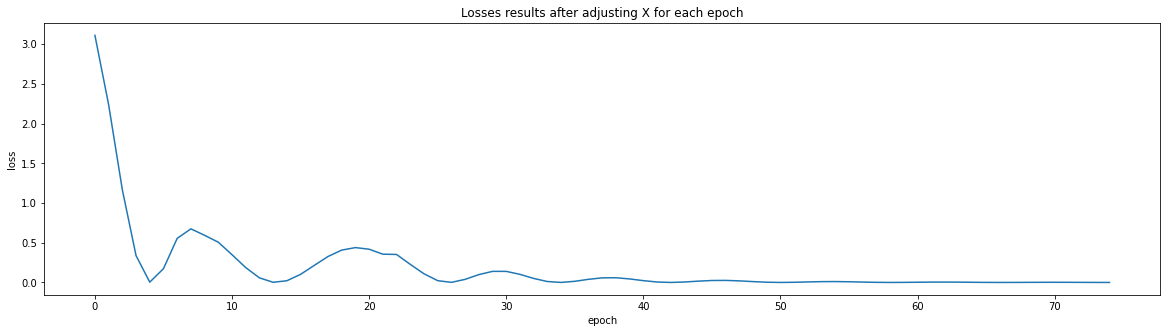

In [57]:
plt.figure(figsize=(20,5))
plt.plot(losses)
plt.title("Losses results after adjusting X for each epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

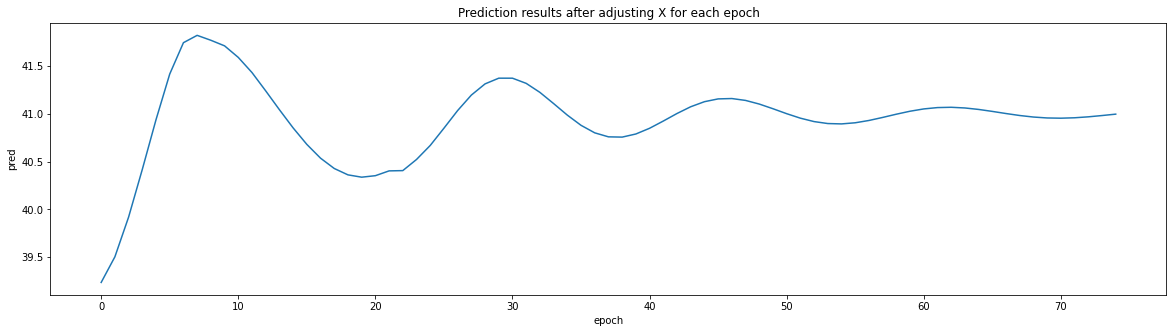

In [58]:
plt.figure(figsize=(20,5))
plt.plot(preds)
plt.title("Prediction results after adjusting X for each epoch")
plt.xlabel("epoch")
plt.ylabel("pred")
plt.show()

#### Final check

In [59]:
# 檢測是否有不可調動的參數被調動
input_X.index = ["init"]
X = pd.DataFrame(X, columns = features, index = ["new"])
update = pd.concat([input_X, X]).T
update["fixed"] = fixed_mask
update["change"] = update.eval("(init != new)").astype(int)
update["check"] = update.eval("not ((init != new) & fixed)").astype(int)
update["pred"] = round(pred_round1, 1)
update

,init,new,fixed,change,check,pred
#1 Turbine motor side pressure,-0.2,-0.20,1,0,1,41.1
#1 Turbine Free Side Pressure,0.4,-37.48,0,1,1,41.1
#1 Turbine Negative Pressure,0.1,0.10,1,0,1,41.1
#1 Turbine Negative Pressure.1,50.0,50.00,1,0,1,41.1
#1 Turbine Main Motor Current,0.3,69.75,0,1,1,41.1
#1 Vacuum Pump Motor Side vibration,0.6,14.25,0,1,1,41.1
#1 Free side vibration of vacuum pump,0.5,0.50,1,0,1,41.1
#2 Turbine motor side pressure,0.4,-48.82,0,1,1,41.1
#2 Turbine free side pressure,-0.4,-0.40,1,0,1,41.1
#2 Turbine negative pressure,0.0,0.00,1,0,1,41.1
